One-for-All model

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import torch 
import torch.nn as nn
import torch.nn.functional as F

In [13]:
import sys, os
sys.path.append(os.path.abspath(".."))

In [14]:
from src.load_sam_data import load_dataset

dataset = load_dataset("FJ")

..\data\FJ\FI01X1\FI01X1_ch


In [15]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
dataset = scaler.fit_transform(dataset)

In [16]:
import torch 

torch_df = torch.from_numpy(dataset)
torch_df = torch_df.to(torch.float32)

In [17]:
from torch.utils.data import Dataset, DataLoader

class HistDataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        x = self.df[idx]

        if not torch.is_tensor(x):
            x = torch.tensor(x, dtype=torch.float32)
        
        x = x.unsqueeze(0)
        return x

In [30]:
import torch.nn as nn

# first model
class Autoencoder(nn.Module):
    def __init__(self, input_dim=96):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_features=input_dim, out_features=96),
            nn.Conv1d(1, 1, kernel_size=6, stride=2, padding=1),  
            nn.BatchNorm1d(1),
            nn.ReLU(),
            nn.Conv1d(1, 1, kernel_size=6, stride=2, padding=1), 
            nn.BatchNorm1d(1),
            nn.Sigmoid()
            )

        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(1, 1, kernel_size=4, stride=2),  
            nn.BatchNorm1d(1),
            nn.ReLU(),
            nn.ConvTranspose1d(1, 1, kernel_size=6, stride=2),
            nn.BatchNorm1d(1),
            nn.Sigmoid()
            )
        
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [31]:
batch_size = 32
torch_small_df = HistDataset(torch_df)
dataloader = DataLoader(torch_small_df, batch_size=batch_size, shuffle=False)

ae_conv = Autoencoder()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(params=ae_conv.parameters(), lr=0.002)

In [32]:
losses = []
n_epochs = 40
ae_conv.train()

for e in range(n_epochs):
    epoch_loss = 0.0
    for pt in dataloader:
        #pt = pt.reshape(batch_size, 1, 96)
        recreated = ae_conv(pt)
        loss = criterion(pt, recreated)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    epoch_loss /= len(dataloader)
    losses.append(epoch_loss)

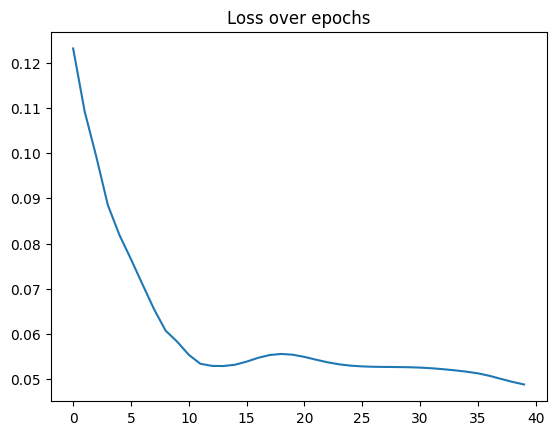

In [33]:
plt.title('Loss over epochs')
plt.plot(range(len(losses)), losses)

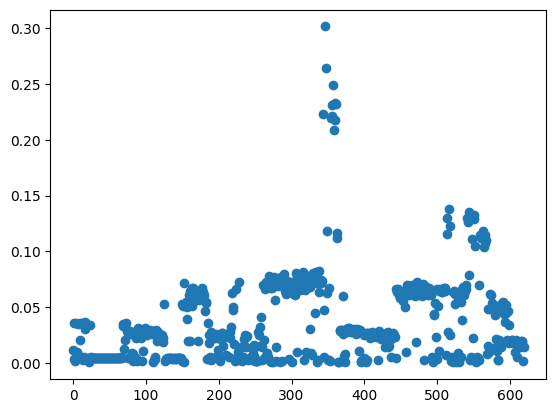

In [34]:
ae_conv.eval()
score = []
for batch in dataloader:
    for pt in batch:
        loss = criterion(ae_conv(pt.unsqueeze(0)), pt)
        score.append(loss.detach().numpy())

plt.scatter(range(len(score)), score)
plt.show()

In [53]:
score_dict = {idx : s for idx, s in enumerate(score)}
indexes_sorted_by_score = sorted(score_dict, key=lambda x: score_dict[x], reverse=True)

indexes_sorted_by_score[:10], indexes_sorted_by_score[-3:]

([346, 347, 357, 359, 361, 356, 343, 355, 354, 360], [284, 274, 300])

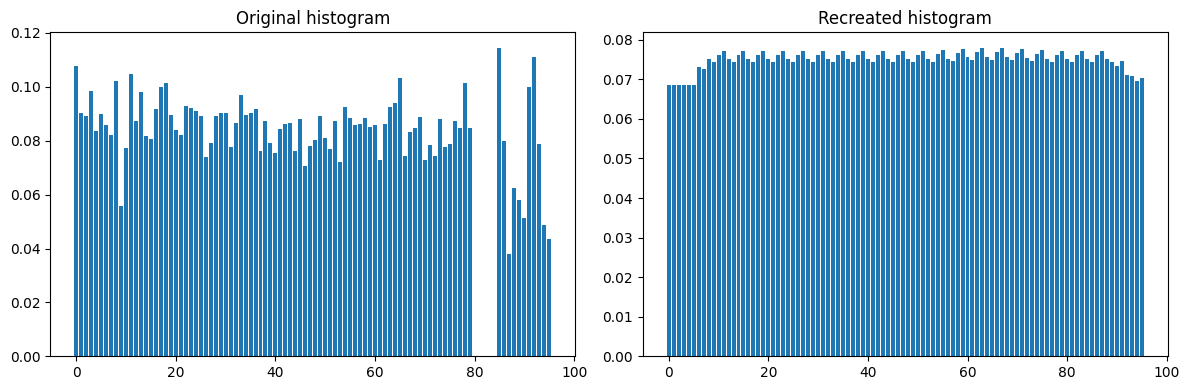

In [57]:
idx = 284
ae_conv.eval()
pred = ae_conv(torch_small_df[idx].unsqueeze(0))
pred = pred.detach().numpy().squeeze()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(len(pred)), dataset[idx])
axes[0].set_title("Original histogram")

axes[1].bar(range(len(pred)), pred)
axes[1].set_title("Recreated histogram")


plt.tight_layout()
plt.show()